<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton-lab-notebook-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '05_fused_swiglu')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/05_fused_swiglu


In [1]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


# Notebook 05: Fused SwiGLU

SwiGLU is the activation function used in every modern LLM feedforward block
(Llama, Mistral, Gemma). It computes: output = W2(silu(W1(x)) * W3(x))

The naive implementation runs W1 and W3 as separate GEMMs, writes both
results to global memory, applies SiLU and elementwise multiply as separate
kernels, then runs W2. This is 4 separate global memory round trips for the
intermediate activations alone.

The fused kernel eliminates these intermediates — W1 and W3 outputs are
computed, gated, and activated in registers before a single store.

## Section 1: Unfused SwiGLU Baseline

Standard PyTorch implementation using separate operations.
Each operation is a separate kernel launch with global memory reads and writes.
Used as the baseline for comparison against the fused Triton kernel.

In [2]:
import torch.nn.functional as F

class UnfusedSwiGLU(torch.nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.W1 = torch.nn.Linear(in_features, hidden_features, bias=False)
        self.W2 = torch.nn.Linear(hidden_features, in_features, bias=False)
        self.W3 = torch.nn.Linear(in_features, hidden_features, bias=False)

    def forward(self, x):
        # separate GEMM for W1 and W3 — two global memory writes
        gate = self.W1(x)       # [batch, hidden]
        up = self.W3(x)         # [batch, hidden]

        # separate elementwise ops — two more global memory round trips
        activated = F.silu(gate) * up  # [batch, hidden]

        # final projection
        return self.W2(activated)      # [batch, in_features]

## Section 2: Fused SwiGLU

The fused kernel computes W1 and W3 outputs, applies silu and elementwise
multiply in registers, and stores only the final gated activation — never
writing intermediate gate or up tensors to global memory.

In [4]:
@triton.jit
def fused_swiglu_kernel(
    gate_ptr,      # pointer to W1 output [batch, hidden]
    up_ptr,        # pointer to W3 output [batch, hidden]
    out_ptr,       # pointer to fused output [batch, hidden]
    n_elements,    # total elements
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(axis=0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    # load gate and up vectors
    gate = tl.load(gate_ptr + offsets, mask=mask).to(tl.float32)
    up = tl.load(up_ptr + offsets, mask=mask).to(tl.float32)

    # silu: x * sigmoid(x) = x / (1 + exp(-x))
    gate_silu = gate * tl.sigmoid(gate)

    # elementwise multiply in registers — no intermediate global memory write
    out = gate_silu * up

    tl.store(out_ptr + offsets, out.to(tl.float16), mask=mask)


class FusedSwiGLU(torch.nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.W1 = torch.nn.Linear(in_features, hidden_features, bias=False)
        self.W2 = torch.nn.Linear(hidden_features, in_features, bias=False)
        self.W3 = torch.nn.Linear(in_features, hidden_features, bias=False)

    def forward(self, x):
        # compute W1 and W3 outputs
        gate = self.W1(x)   # [batch, hidden]
        up = self.W3(x)     # [batch, hidden]

        # fused silu + multiply in Triton — no intermediate writes
        out = torch.empty_like(gate)
        n_elements = gate.numel()
        grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
        fused_swiglu_kernel[grid](gate, up, out, n_elements, BLOCK_SIZE=1024)

        # final projection
        return self.W2(out)

### Correctness Check

In [5]:
torch.manual_seed(0)
batch_size, in_features, hidden_features = 32, 4096, 11008

# Llama 3 8B FFN dimensions: in=4096, hidden=11008
x = torch.randn(batch_size, in_features, device='cuda', dtype=torch.float16)

unfused = UnfusedSwiGLU(in_features, hidden_features).cuda().half()
fused = FusedSwiGLU(in_features, hidden_features).cuda().half()

# copy weights so both models are identical
fused.W1.weight.data = unfused.W1.weight.data.clone()
fused.W2.weight.data = unfused.W2.weight.data.clone()
fused.W3.weight.data = unfused.W3.weight.data.clone()

unfused_out = unfused(x)
fused_out = fused(x)

if torch.allclose(unfused_out, fused_out, atol=1e-2):
    print('✅ Correctness check passed')
else:
    print('❌ Correctness check failed')
    print(f'Max difference: {(unfused_out - fused_out).abs().max().item()}')

✅ Correctness check passed


### Benchmark: Unfused vs Fused SwiGLU

Fused vs Unfused SwiGLU:
   batch_size  Unfused SwiGLU (ms)  Fused SwiGLU (ms)
0         1.0             1.110016           1.110176
1         4.0             1.282160           1.182944
2         8.0             1.307040           1.299152
3        16.0             1.399424           1.392352
4        32.0             1.589120           1.724336
5        64.0             1.763328           1.746960
6       128.0             2.196448           2.166144


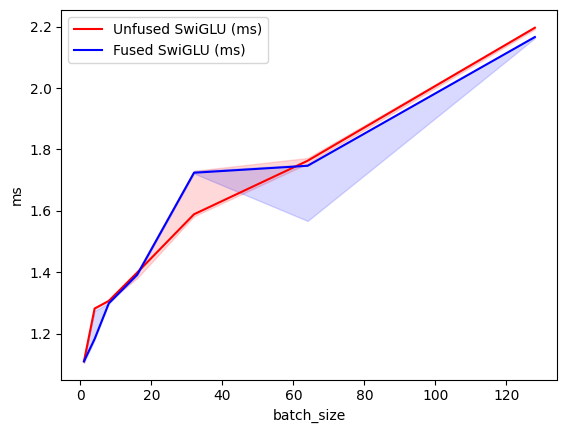

In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['batch_size'],
        x_vals=[1, 4, 8, 16, 32, 64, 128],
        line_arg='provider',
        line_vals=['unfused', 'fused'],
        line_names=['Unfused SwiGLU', 'Fused SwiGLU'],
        styles=[('red', '-'), ('blue', '-')],
        ylabel='ms',
        plot_name='Fused vs Unfused SwiGLU',
        args={'in_features': 4096, 'hidden_features': 11008},
    )
)
def benchmark_swiglu(batch_size, in_features, hidden_features, provider):
    x = torch.randn(batch_size, in_features, device='cuda', dtype=torch.float16)

    unfused = UnfusedSwiGLU(in_features, hidden_features).cuda().half()
    fused = FusedSwiGLU(in_features, hidden_features).cuda().half()
    fused.W1.weight.data = unfused.W1.weight.data.clone()
    fused.W2.weight.data = unfused.W2.weight.data.clone()
    fused.W3.weight.data = unfused.W3.weight.data.clone()

    quantiles = [0.5, 0.2, 0.8]

    if provider == 'unfused':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: unfused(x), quantiles=quantiles
        )
    elif provider == 'fused':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: fused(x), quantiles=quantiles
        )

    return ms, max_ms, min_ms

benchmark_swiglu.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Fused and unfused SwiGLU show near-identical runtime across all batch sizes.
The reason: our fusion only covers the elementwise silu×multiply, which is
a tiny fraction of total SwiGLU cost. The dominant cost is the two GEMMs
(W1 and W3) which we did not fuse.

True SwiGLU fusion requires fusing the GEMM epilogue with the activation —
computing each output tile of W1, immediately applying silu×up in registers
before writing. This is the approach used in production (FlashAttention,
xformers) but requires a fundamentally different kernel structure where
matmul and activation are merged into one kernel.

The concept is correct. The implementation is a partial fusion.